# 03 — Spectral Bandpower EDA

Explores bandpower in δ, θ, α, β, γ bands per channel. Directly informs **BOCPD feature choice** (deep-research-report: run BOCPD on log bandpower). Checks distributions, typical ranges, and which bands carry most signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import welch

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else (Path.cwd() / ".." / "..").resolve()
DATA_ROOT = ROOT / "data"
ARTIFACTS_DIR = ROOT / "artifacts" / "figures" / "spectral_bandpower"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
PARTICIPANTS = [f"sub-{i:02d}" for i in range(1, 11)]
DATE_TAG = "2026-02-25"
FS = 100

In [2]:
def load_preprocessed(path):
    d = np.load(path, allow_pickle=True).item()
    return d["preprocessed_eeg_data"], d["ch_names"], d["times"]

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 50),
}

def bandpower_from_psd(freqs, psd, low, high):
    idx = (freqs >= low) & (freqs <= high)
    return np.trapz(psd[idx], freqs[idx])

def compute_bandpower(x, fs=100):
    """x: 1D array (one trial, one channel). Returns dict of band -> power."""
    f, psd = welch(x, fs=fs, nperseg=min(64, len(x)))
    return {b: bandpower_from_psd(f, psd, lo, hi) for b, (lo, hi) in BANDS.items()}

## 1. Compute bandpower per trial (sample of conditions)

Use train data; sample conditions to keep computation tractable. Per trial, per channel: compute bandpower in each band.

In [3]:
N_COND_SAMPLE = 500
np.random.seed(42)

all_bp = []
for sub in PARTICIPANTS:
    p = DATA_ROOT / sub / "preprocessed_eeg_training.npy"
    if not p.exists():
        continue
    X, ch_names, times = load_preprocessed(p)
    cond_idx = np.random.choice(X.shape[0], size=min(N_COND_SAMPLE, X.shape[0]), replace=False)
    for c in cond_idx:
        for rep in range(X.shape[1]):
            for ch in range(X.shape[2]):
                bp = compute_bandpower(X[c, rep, ch, :], fs=FS)
                for band, val in bp.items():
                    all_bp.append({
                        "participant": sub,
                        "condition": c,
                        "rep": rep,
                        "channel": ch_names[ch],
                        "band": band,
                        "power": val,
                        "log_power": np.log(val + 1e-10),
                    })

bp_df = pd.DataFrame(all_bp)
print(f"Computed {len(bp_df)} bandpower values ({len(bp_df) / len(BANDS) / 17:.0f} trials)")

Computed 1700000 bandpower values (20000 trials)


## 2. Bandpower by band (mean across participants)

In [4]:
band_summary = bp_df.groupby("band")["power"].agg(["mean", "std", "median"]).reindex(list(BANDS.keys()))
band_summary["log_mean"] = bp_df.groupby("band")["log_power"].mean()
band_summary["log_std"] = bp_df.groupby("band")["log_power"].std()
print(band_summary.to_string())

           mean       std    median  log_mean   log_std
band                                                   
delta  0.044882  0.652242  0.031504 -3.505773  0.906333
theta  0.073587  0.877805  0.046316 -3.074233  0.949582
alpha  0.065746  0.113278  0.040455 -3.201775  0.999754
beta   0.064361  0.197571  0.050470 -2.985544  0.727149
gamma  0.024368  0.153388  0.013005 -4.271060  0.957432


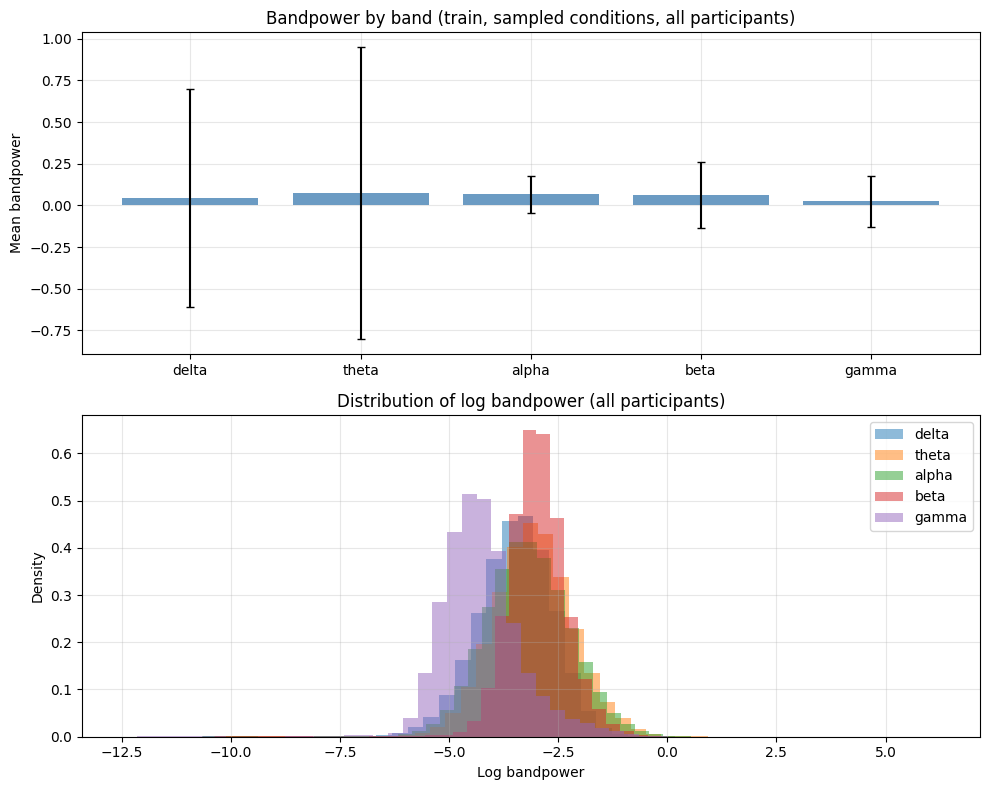

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
bands_ord = list(BANDS.keys())
bp_by_band = bp_df.groupby("band")["power"].agg(["mean", "std"]).reindex(bands_ord)
axes[0].bar(bands_ord, bp_by_band["mean"], yerr=bp_by_band["std"], capsize=3, color="steelblue", alpha=0.8)
axes[0].set_ylabel("Mean bandpower")
axes[0].set_title("Bandpower by band (train, sampled conditions, all participants)")
axes[0].grid(True, alpha=0.3)

for band in bands_ord:
    axes[1].hist(bp_df[bp_df["band"] == band]["log_power"], bins=50, alpha=0.5, label=band, density=True)
axes[1].set_xlabel("Log bandpower")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of log bandpower (all participants)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"spectral__bandpower_by_band__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Bandpower by channel (which channels have most power?)

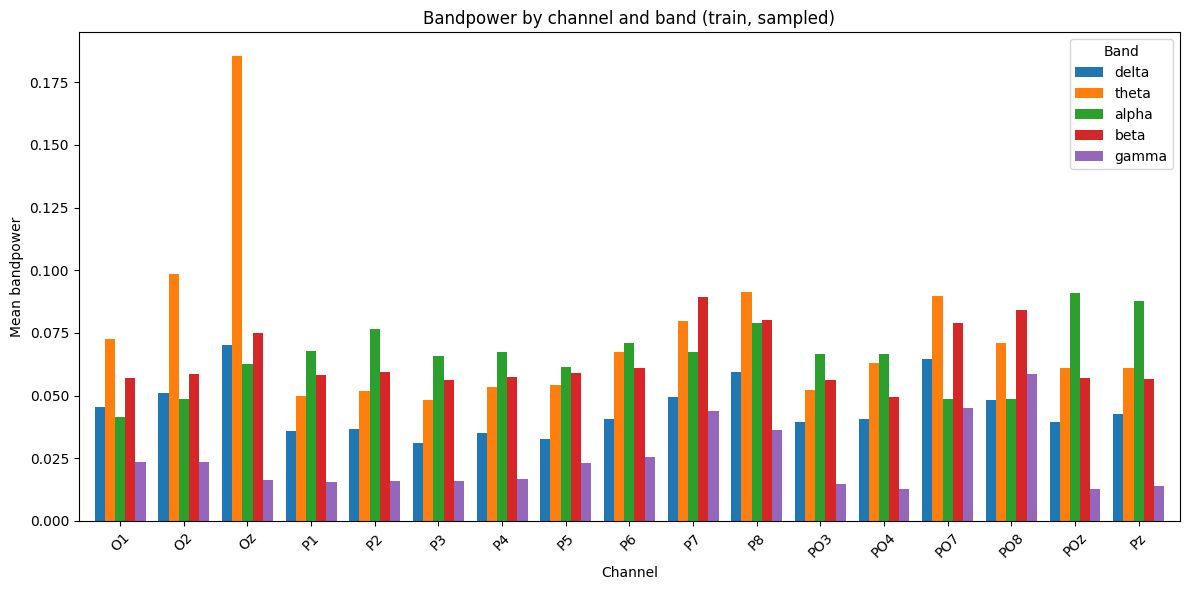

In [6]:
ch_band_summary = bp_df.groupby(["channel", "band"])["power"].mean().unstack(fill_value=0)
ch_band_summary = ch_band_summary[list(BANDS.keys())]

fig, ax = plt.subplots(figsize=(12, 6))
ch_band_summary.plot(kind="bar", ax=ax, width=0.8)
ax.set_xlabel("Channel")
ax.set_ylabel("Mean bandpower")
ax.set_title("Bandpower by channel and band (train, sampled)")
ax.legend(title="Band")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"spectral__bandpower_by_channel__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Summary table (mean, std per participant × band)

In [7]:
summary_rows = []
for sub in PARTICIPANTS:
    d = bp_df[bp_df["participant"] == sub]
    for band in BANDS:
        bd = d[d["band"] == band]["log_power"]
        summary_rows.append({
            "participant": sub,
            "band": band,
            "log_power_mean": bd.mean(),
            "log_power_std": bd.std(),
            "power_mean": d[d["band"] == band]["power"].mean(),
        })

summary_df = pd.DataFrame(summary_rows)
tables_dir = ROOT / "artifacts" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(tables_dir / f"spectral__bandpower_summary__{DATE_TAG}.csv", index=False)
print(summary_df.pivot(index="participant", columns="band", values="log_power_mean").to_string())

band            alpha      beta     delta     gamma     theta
participant                                                  
sub-01      -2.640905 -3.368030 -3.560682 -5.065675 -2.785287
sub-02      -3.088236 -2.783484 -3.793205 -4.066953 -3.247311
sub-03      -3.274091 -2.967162 -3.523104 -4.343986 -2.925711
sub-04      -3.632631 -3.527705 -3.733384 -5.202464 -3.345738
sub-05      -3.676561 -2.718042 -3.210943 -3.448359 -3.274989
sub-06      -3.600000 -2.964073 -3.311530 -3.691808 -3.247872
sub-07      -2.661983 -2.767564 -3.786339 -4.812389 -3.192006
sub-08      -3.207778 -3.101521 -3.306991 -4.163887 -2.564218
sub-09      -3.279147 -2.695551 -3.478216 -3.444809 -3.082635
sub-10      -2.956413 -2.962313 -3.353331 -4.470271 -3.076559


## 5. Distribution check: Gaussian vs log-normal

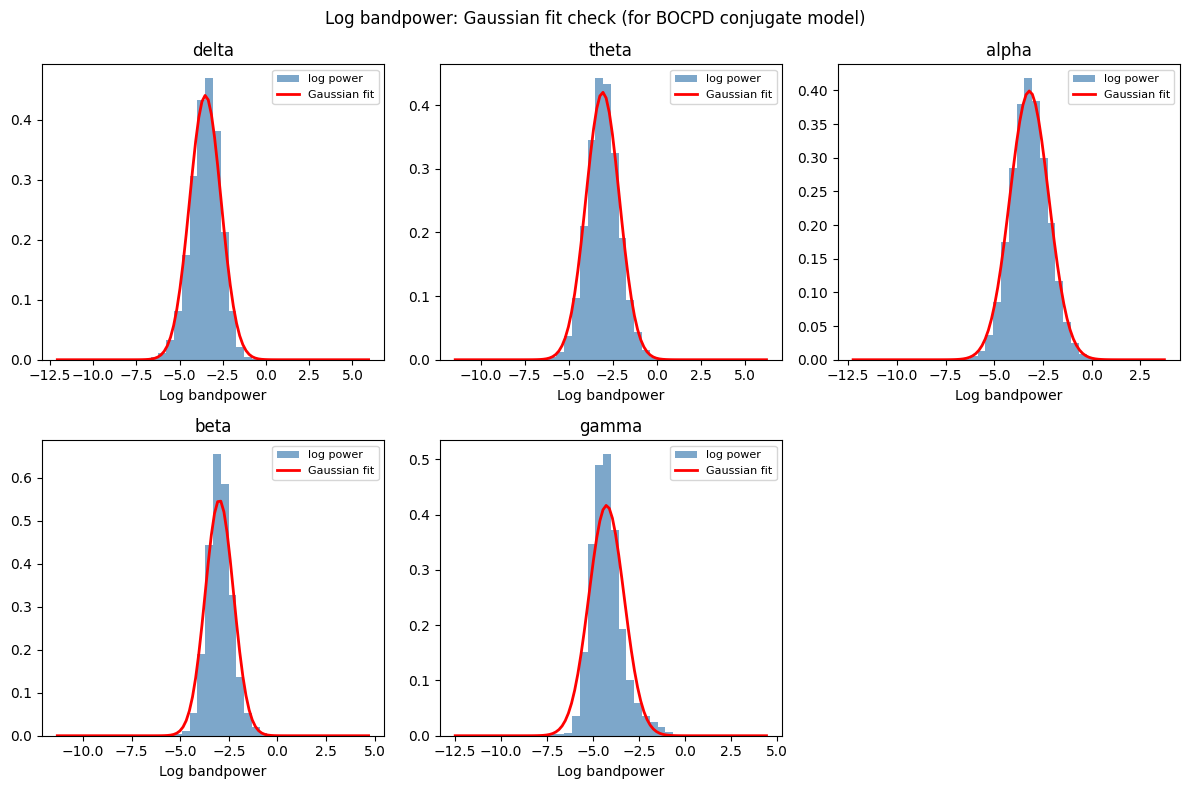

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, band in enumerate(list(BANDS.keys())[:5]):
    log_vals = bp_df[bp_df["band"] == band]["log_power"]
    axes[i].hist(log_vals, bins=40, density=True, alpha=0.7, label="log power", color="steelblue")
    mu, sig = log_vals.mean(), log_vals.std()
    x = np.linspace(log_vals.min(), log_vals.max(), 100)
    axes[i].plot(x, np.exp(-0.5 * ((x - mu) / sig) ** 2) / (sig * np.sqrt(2 * np.pi)), "r-", lw=2, label="Gaussian fit")
    axes[i].set_title(f"{band}")
    axes[i].set_xlabel("Log bandpower")
    axes[i].legend(fontsize=8)
axes[5].axis("off")
plt.suptitle("Log bandpower: Gaussian fit check (for BOCPD conjugate model)")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"spectral__log_power_gaussian_check__{DATE_TAG}.png", dpi=200, bbox_inches="tight")
plt.show()